In [6]:
from openmm import Vec3, unit
from openmm.app import Element, ForceField, Modeller, PDBFile, Topology

In [82]:
top = Topology()
chain = top.addChain()
res = top.addResidue("CL", chain)
top.addAtom("Cl", Element.getBySymbol("Cl"), res, formalCharge=-1)
res = top.addResidue("NA", chain)
top.addAtom("Na", Element.getBySymbol("Na"), res, formalCharge=+1)

modeller = Modeller(top, [Vec3(0.1, 0.1, 0.1), Vec3(22.0, 13.0, 5.5)])
modeller.addMembrane(
    forcefield=ForceField("amber14-all.xml", "amber14/tip3pfb.xml"),
    lipidType="DLPC",
    membraneCenterZ=unit.Quantity(value=2.7, unit=unit.nanometer),
    minimumPadding=unit.Quantity(value=0, unit=unit.nanometer),
    positiveIon="Na+",
    negativeIon="Cl-",
    ionicStrength=unit.Quantity(value=0.1, unit=unit.molar),
    neutralize=True,
)
print(modeller.topology.getNumAtoms())

200468


In [83]:
from io import StringIO
from pathlib import Path


def dlp_to_dlpe(line: str) -> str:
    if line[17:21] == "DLP ":
        line = list(line)
        line[17:21] = "DLPC"
        line = "".join(line)
    return line


with StringIO() as f:
    PDBFile.writeFile(modeller.topology, modeller.positions, f)
    pdb_lines = [dlp_to_dlpe(line) for line in f.getvalue().splitlines()]

Path(f"../openff/pablo/_tests/data/big_bilayer2.pdb").write_text("\n".join(pdb_lines))

18615866

In [84]:
len([*modeller.topology.residues()])

31740

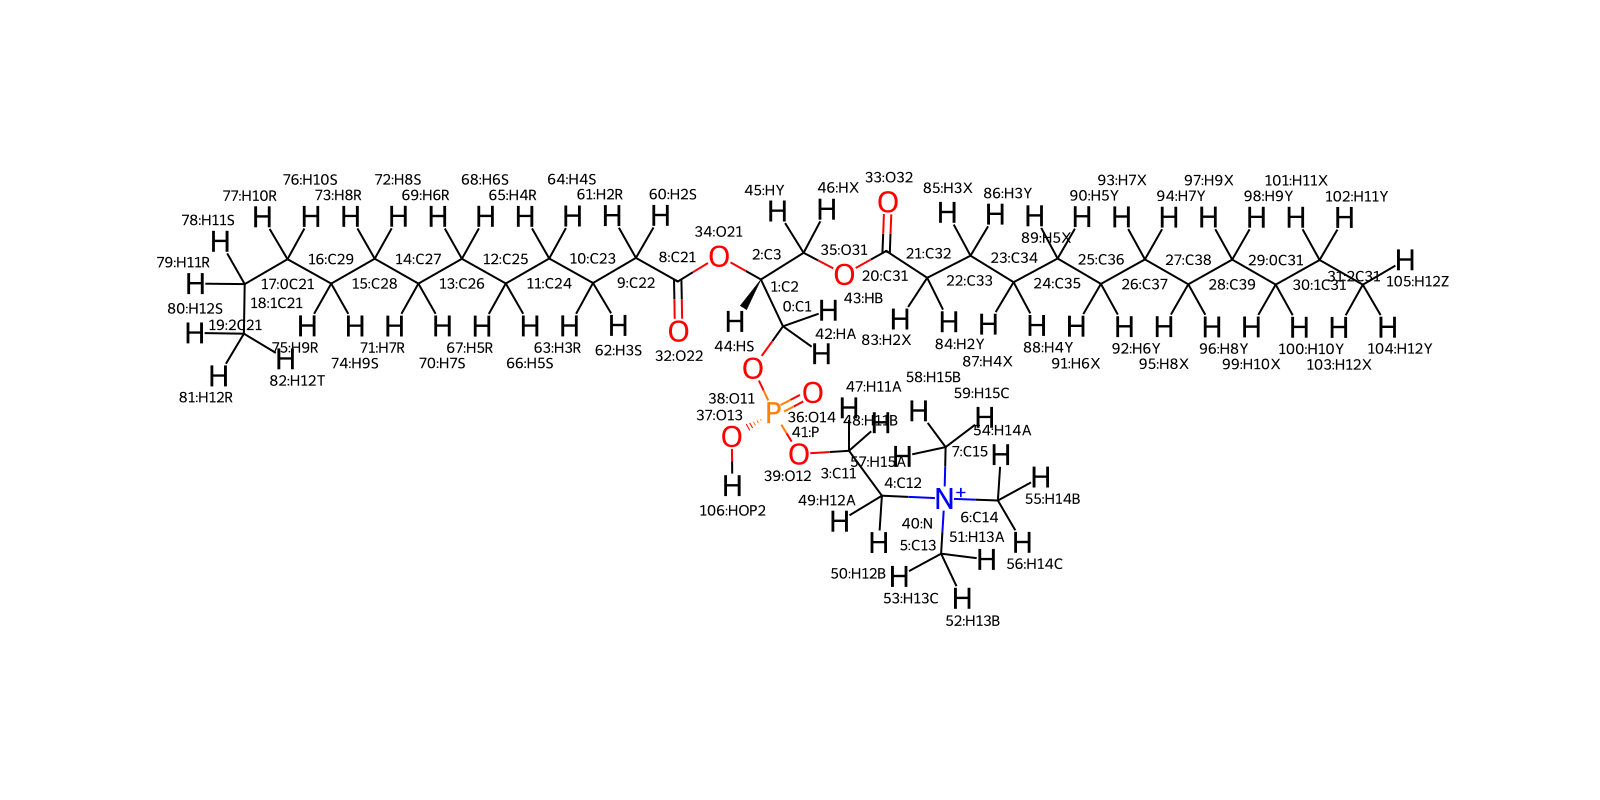

In [112]:
from openff.pablo import CCD_RESIDUE_DEFINITION_CACHE
from openff.pablo._utils import draw_molecule
from openff.toolkit import Molecule

# names = {
#     1: "O13",
#     2: "P",
#     3: "
# }

# mol = Molecule.from_mapped_smiles(
#     "[O-:1][P:2]([O:3][C:4]([C:5]([N+:6]([C:7]([H:60])([H:61])[H:62])([C:8]([H:63])([H:64])[H:65])[C:9]([H:66])([H:67])[H:68])([H:58])[H:59])([H:56])[H:57])([O:10][C:11]([C@:12]([H:13])([O:14][C:15]([C:16]([C:17]([C:18]([C:19]([C:20]([C:21]([C:22](/[C:23](=[C:24](\\[C:25](/[C:26](=[C:27](\\[C:28]([C:29]([C:30]([C:31]([C:32]([H:99])([H:100])[H:101])([H:97])[H:98])([H:95])[H:96])([H:93])[H:94])([H:91])[H:92])[H:90])[H:89])([H:87])[H:88])[H:86])[H:85])([H:83])[H:84])([H:81])[H:82])([H:79])[H:80])([H:77])[H:78])([H:75])[H:76])([H:73])[H:74])([H:71])[H:72])=[O:33])[C:34]([O:35][C:36]([C:37]([C:38]([C:39]([C:40]([C:41]([C:42]([C:43](/[C:44](=[C:45](\\[C:46](/[C:47](=[C:48](\\[C:49]([C:50]([C:51]([C:52]([C:53]([H:132])([H:133])[H:134])([H:130])[H:131])([H:128])[H:129])([H:126])[H:127])([H:124])[H:125])[H:123])[H:122])([H:120])[H:121])[H:119])[H:118])([H:116])[H:117])([H:114])[H:115])([H:112])[H:113])([H:110])[H:111])([H:108])[H:109])([H:106])[H:107])([H:104])[H:105])=[O:54])([H:102])[H:103])([H:69])[H:70])=[O:55]",
#     allow_undefined_stereo=True,
# )

mol = CCD_RESIDUE_DEFINITION_CACHE["PLC"][0].to_openff_molecule()

names = {i: atom.name for i, atom in enumerate(mol.atoms)}
names.update(
    {
        42: "HA",
        43: "HB",
        44: "HS",
        45: "HY",
        46: "HX",
        3: "C11",
        47: "H11A",
        48: "H11B",
        4: "C12",
        49: "H12A",
        50: "H12B",
        5: "C13",
        51: "H13A",
        52: "H13B",
        53: "H13C",
        6: "C14",
        54: "H14A",
        55: "H14B",
        56: "H14C",
        7: "C15",
        57: "H15A",
        58: "H15B",
        59: "H15C",
        8: "C21",
        9: "C22",
        60: "H2S",
        61: "H2R",
        10: "C23",
        62: "H3S",
        63: "H3R",
        11: "C24",
        64: "H4S",
        65: "H4R",
        12: "C25",
        66: "H5S",
        67: "H5R",
        13: "C26",
        68: "H6S",
        69: "H6R",
        14: "C27",
        70: "H7S",
        71: "H7R",
        15: "C28",
        72: "H8S",
        73: "H8R",
        16: "C29",
        74: "H9S",
        75: "H9R",
        17: "0C21",
        76: "H10S",
        77: "H10R",
        18: "1C21",
        78: "H11S",
        79: "H11R",
        19: "2C21",
        80: "H12S",
        81: "H12R",
        82: "H12T",
        20: "C31",
        21: "C32",
        83: "H2X",
        84: "H2Y",
        22: "C33",
        85: "H3X",
        86: "H3Y",
        23: "C34",
        87: "H4X",
        88: "H4Y",
        24: "C35",
        89: "H5X",
        90: "H5Y",
        25: "C36",
        91: "H6X",
        92: "H6Y",
        26: "C37",
        93: "H7X",
        94: "H7Y",
        27: "C38",
        95: "H8X",
        96: "H8Y",
        28: "C39",
        97: "H9X",
        98: "H9Y",
        29: "0C31",
        99: "H10X",
        100: "H10Y",
        30: "1C31",
        101: "H11X",
        102: "H11Y",
        31: "2C31",
        103: "H12X",
        104: "H12Y",
        105: "H12Z",
        32: "O22",
        33: "O32",
        34: "O21",
        35: "O31",
        36: "O14",
        37: "O13",
        38: "O11",
        39: "O12",
    }
)

draw_molecule(
    mol,
    height=800,
    width=1600,
    atom_notes={i: f"{i}:{names.get(i, '')}" for i in range(mol.n_atoms)},
)

In [114]:
{k + 1: v for k, v in names.items()}

{1: 'C1',
 2: 'C2',
 3: 'C3',
 4: 'C11',
 5: 'C12',
 6: 'C13',
 7: 'C14',
 8: 'C15',
 9: 'C21',
 10: 'C22',
 11: 'C23',
 12: 'C24',
 13: 'C25',
 14: 'C26',
 15: 'C27',
 16: 'C28',
 17: 'C29',
 18: '0C21',
 19: '1C21',
 20: '2C21',
 21: 'C31',
 22: 'C32',
 23: 'C33',
 24: 'C34',
 25: 'C35',
 26: 'C36',
 27: 'C37',
 28: 'C38',
 29: 'C39',
 30: '0C31',
 31: '1C31',
 32: '2C31',
 33: 'O22',
 34: 'O32',
 35: 'O21',
 36: 'O31',
 37: 'O14',
 38: 'O13',
 39: 'O11',
 40: 'O12',
 41: 'N',
 42: 'P',
 43: 'HA',
 44: 'HB',
 45: 'HS',
 46: 'HY',
 47: 'HX',
 48: 'H11A',
 49: 'H11B',
 50: 'H12A',
 51: 'H12B',
 52: 'H13A',
 53: 'H13B',
 54: 'H13C',
 55: 'H14A',
 56: 'H14B',
 57: 'H14C',
 58: 'H15A',
 59: 'H15B',
 60: 'H15C',
 61: 'H2S',
 62: 'H2R',
 63: 'H3S',
 64: 'H3R',
 65: 'H4S',
 66: 'H4R',
 67: 'H5S',
 68: 'H5R',
 69: 'H6S',
 70: 'H6R',
 71: 'H7S',
 72: 'H7R',
 73: 'H8S',
 74: 'H8R',
 75: 'H9S',
 76: 'H9R',
 77: 'H10S',
 78: 'H10R',
 79: 'H11S',
 80: 'H11R',
 81: 'H12S',
 82: 'H12R',
 83: 'H12T',

In [116]:
mol.to_smiles(mapped=True)

'[C:1]([C@@:2]([C:3]([O:36][C:21]([C:22]([C:23]([C:24]([C:25]([C:26]([C:27]([C:28]([C:29]([C:30]([C:31]([C:32]([H:104])([H:105])[H:106])([H:102])[H:103])([H:100])[H:101])([H:98])[H:99])([H:96])[H:97])([H:94])[H:95])([H:92])[H:93])([H:90])[H:91])([H:88])[H:89])([H:86])[H:87])([H:84])[H:85])=[O:34])([H:46])[H:47])([O:35][C:9]([C:10]([C:11]([C:12]([C:13]([C:14]([C:15]([C:16]([C:17]([C:18]([C:19]([C:20]([H:81])([H:82])[H:83])([H:79])[H:80])([H:77])[H:78])([H:75])[H:76])([H:73])[H:74])([H:71])[H:72])([H:69])[H:70])([H:67])[H:68])([H:65])[H:66])([H:63])[H:64])([H:61])[H:62])=[O:33])[H:45])([O:39][P@:42](=[O:37])([O:38][H:107])[O:40][C:4]([C:5]([N+:41]([C:6]([H:52])([H:53])[H:54])([C:7]([H:55])([H:56])[H:57])[C:8]([H:58])([H:59])[H:60])([H:50])[H:51])([H:48])[H:49])([H:43])[H:44]'

In [117]:
mol2 = Molecule.from_mapped_smiles(
    "[C:1]([C@@:2]([C:3]([O:36][C:21]([C:22]([C:23]([C:24]([C:25]([C:26]([C:27]([C:28]([C:29]([C:30]([C:31]([C:32]([H:104])([H:105])[H:106])([H:102])[H:103])([H:100])[H:101])([H:98])[H:99])([H:96])[H:97])([H:94])[H:95])([H:92])[H:93])([H:90])[H:91])([H:88])[H:89])([H:86])[H:87])([H:84])[H:85])=[O:34])([H:46])[H:47])([O:35][C:9]([C:10]([C:11]([C:12]([C:13]([C:14]([C:15]([C:16]([C:17]([C:18]([C:19]([C:20]([H:81])([H:82])[H:83])([H:79])[H:80])([H:77])[H:78])([H:75])[H:76])([H:73])[H:74])([H:71])[H:72])([H:69])[H:70])([H:67])[H:68])([H:65])[H:66])([H:63])[H:64])([H:61])[H:62])=[O:33])[H:45])([O:39][P@:42](=[O:37])([O-:38])[O:40][C:4]([C:5]([N+:41]([C:6]([H:52])([H:53])[H:54])([C:7]([H:55])([H:56])[H:57])[C:8]([H:58])([H:59])[H:60])([H:50])[H:51])([H:48])[H:49])([H:43])[H:44]",
    allow_undefined_stereo=True,
)

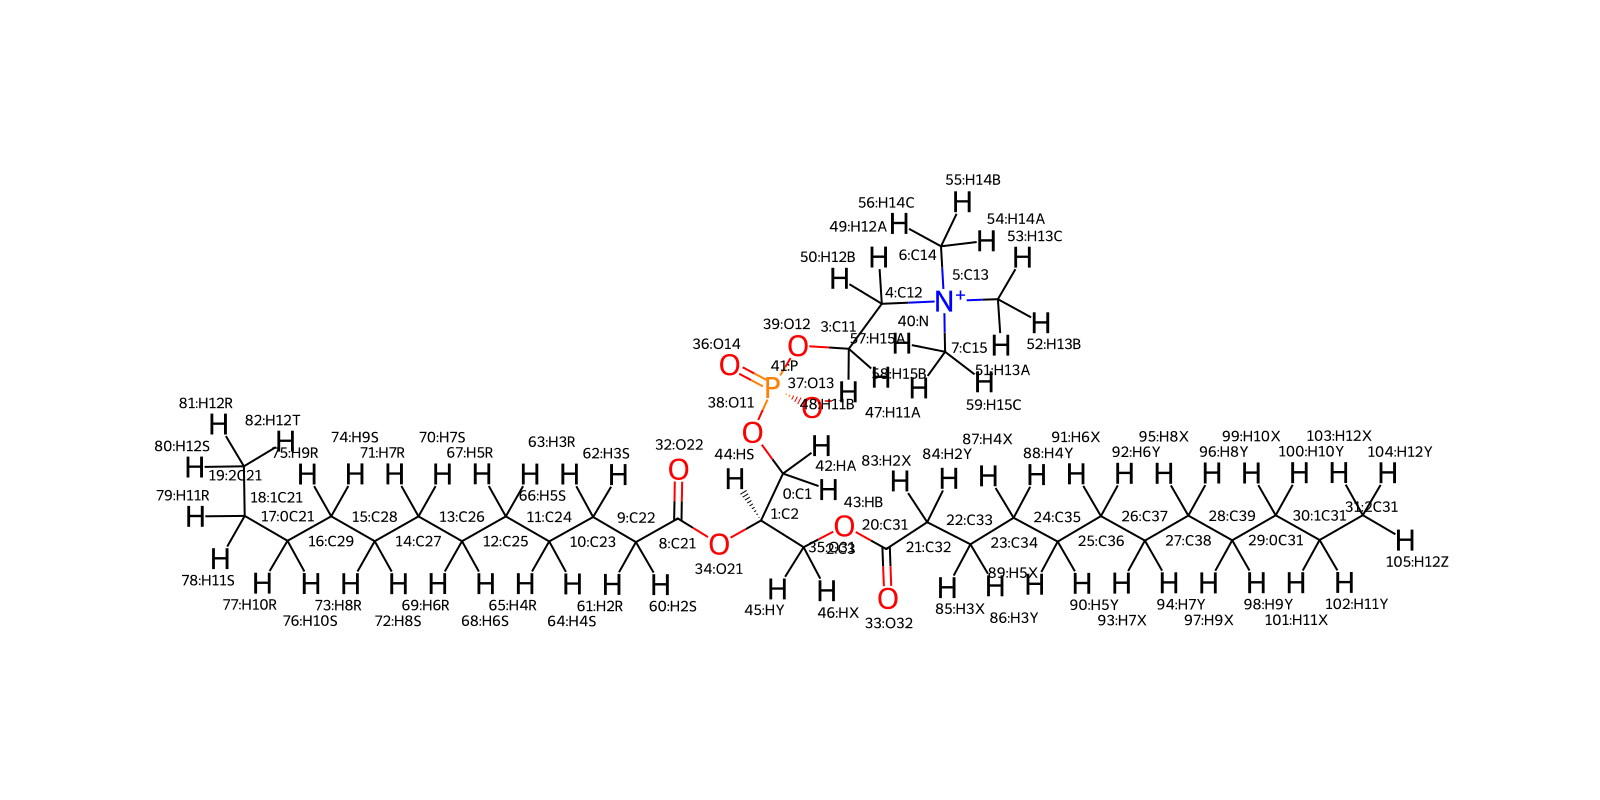

In [118]:
draw_molecule(
    mol2,
    height=800,
    width=1600,
    atom_notes={i: f"{i}:{names.get(i, '')}" for i in range(mol.n_atoms)},
)

In [119]:
from openff.pablo._utils import dec_hex

dec_hex("FFFFF")

493215